In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
data = pd.read_csv("smartphone_overheating_dataset.csv")

print(data.head(20))

    Battery_Temp_C  CPU_Temp_C  Ambient_Temp_C  CPU_Usage_Pct  GPU_Usage_Pct  \
0        38.483571   50.244757       29.510183      35.980335       0.235407   
1        35.308678   32.757162       38.118758      63.838575      55.485441   
2        39.238443   46.603498       44.661971      86.824548      44.509109   
3        43.615149   37.046092       43.407392      33.084809      93.555151   
4        34.829233   39.380778       25.699396      14.717118       4.915744   
5        34.829315   42.380834       25.882436      48.244084      53.170198   
6        43.896064   41.044072       18.040804       7.731435       3.590913   
7        39.837174   28.591155       40.622195      48.847486      62.455133   
8        33.652628   53.054496       22.376601      71.303363      86.608205   
9        38.712800   51.075274       28.347276      56.147179      24.924721   
10       33.682912   40.829468       34.357792      93.105282      36.253795   
11       33.671351   49.475189       42.

In [35]:
X = data.drop('Overheating_Status', axis=1)

y = data['Overheating_Status']

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

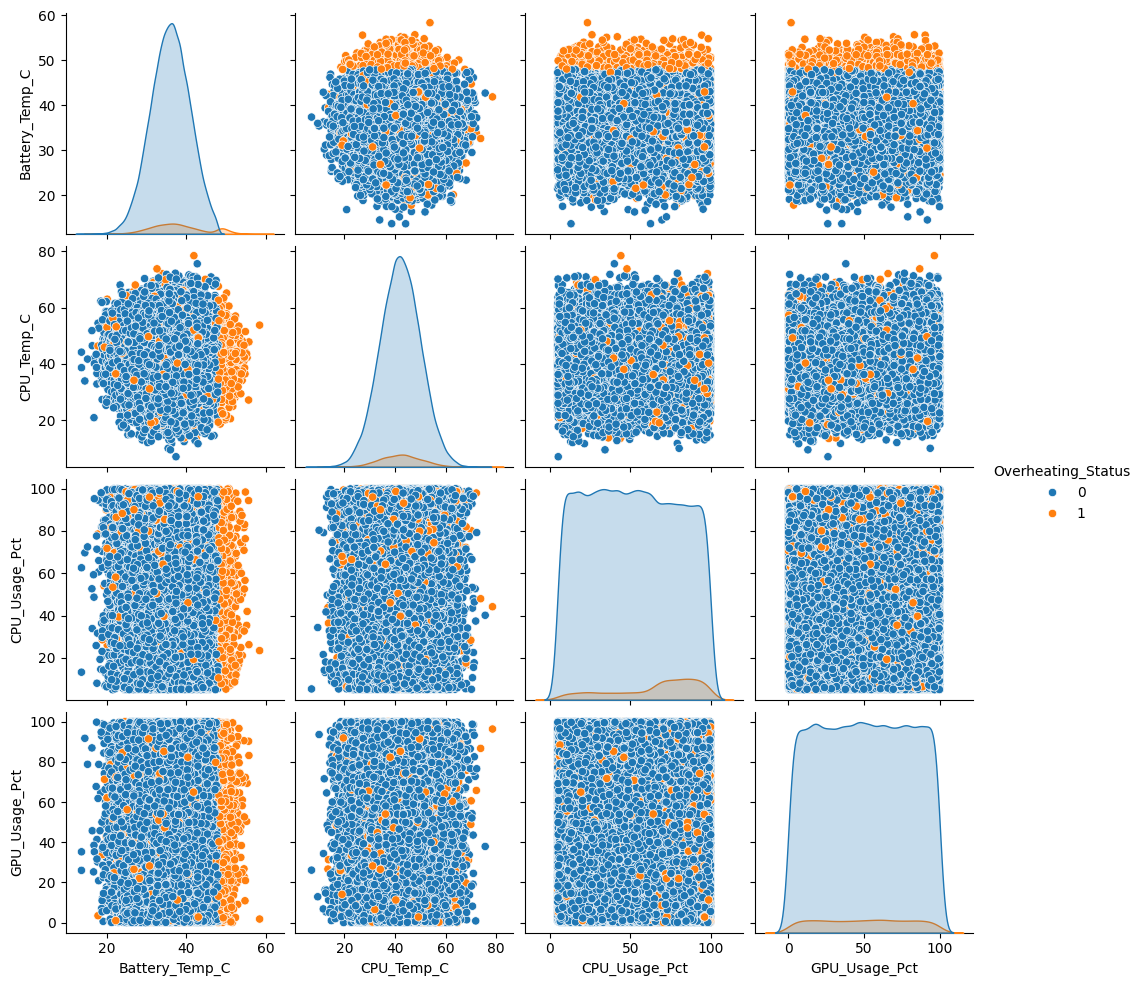

In [37]:
sns.pairplot(
    data[['Battery_Temp_C',
          'CPU_Temp_C',
          'CPU_Usage_Pct',
          'GPU_Usage_Pct',
          'Overheating_Status']],
    hue='Overheating_Status'
)

plt.show()

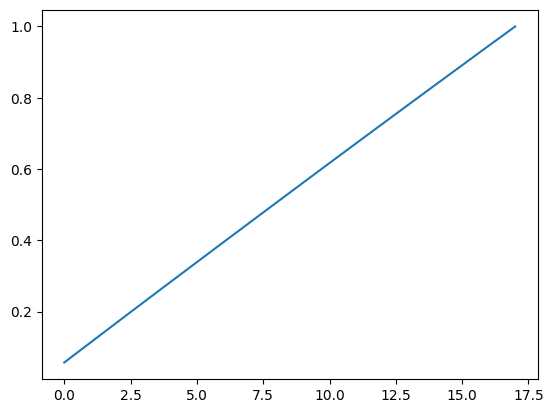

In [38]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

plt.plot(
    np.cumsum(pca.explained_variance_ratio_)
)

plt.show()

In [39]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=8
)

X_selected = selector.fit_transform(X_scaled, y)

print(selector.scores_)

[9.22199985e+02 6.28026952e+00 2.42598882e+03 1.25881064e+03
 2.59569561e-01 1.67695938e+00 1.12382989e+00 7.83912506e-04
 1.70107605e-01 1.90473070e+03 2.50471744e+03 1.04424284e-01
 4.43193515e+00 2.54106479e+03 4.49654562e-01 7.59417577e-01
 3.95447223e-01 8.67860046e-01]


In [40]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

rfe = RFE(
    lr,
    n_features_to_select=8
)

X_rfe = rfe.fit_transform(X_scaled, y)

print(rfe.support_)

[ True  True  True  True  True False False False False  True  True False
 False  True False False False False]


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [43]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(name)

    print("Accuracy :", accuracy_score(y_test, y_pred))

    print("Precision :", precision_score(y_test, y_pred))

    print("Recall :", recall_score(y_test, y_pred))

    print("F1 Score :", f1_score(y_test, y_pred))

NameError: name 'models' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(name)

    plt.show()